In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import seaborn as sns

data_path = "../emissions_corrected"
training_phase_data_raw = pd.read_csv(f"{data_path}/run_params_training_phase.csv", index_col=False)
prompting_phase_data_raw = pd.read_csv(f"{data_path}/run_params_prompting_phase.csv", index_col=False)
emissions_raw = pd.read_csv(f"{data_path}/emissions.csv")

In [16]:
training_phase_data_cpu = training_phase_data_raw[training_phase_data_raw["DEVICE"]=="cpu"]
training_phase_data_mps = training_phase_data_raw[training_phase_data_raw["DEVICE"]=="mps"]
prompting_phase_data_cpu = prompting_phase_data_raw[prompting_phase_data_raw["DEVICE"]=="cpu"]
prompting_phase_data_mps = prompting_phase_data_raw[prompting_phase_data_raw["DEVICE"]=="mps"]

training_phase_data_cpu \
    .merge(emissions_raw, on="run_id") \
    [["run_id",  "BATCH_SIZE", "N_LAYER", "N_EMBD", "training_time_secs", "emissions_x", "energy_consumed"]] \
    .to_csv(f"{data_path}/train_cpu.csv")

training_phase_data_mps \
    .merge(emissions_raw, on="run_id") \
    [["run_id",  "BATCH_SIZE", "N_LAYER", "N_EMBD", "training_time_secs", "emissions_x", "energy_consumed"]] \
    .to_csv(f"{data_path}/train_mps.csv")

prompting_phase_data_cpu \
    .merge(emissions_raw, on="run_id") \
    [["run_id",  "MAX_NEW_TOKENS", "TEMPERATURE", "TOP_K", "training_time_secs", "emissions_x", "energy_consumed"]] \
    .to_csv(f"{data_path}/prompt_cpu.csv")

prompting_phase_data_mps \
    .merge(emissions_raw, on="run_id") \
    [["run_id",  "MAX_NEW_TOKENS", "TEMPERATURE", "TOP_K", "training_time_secs", "emissions_x", "energy_consumed"]] \
    .to_csv(f"{data_path}/prompt_mps.csv")

In [93]:

latex_train_cpu = training_phase_data_cpu \
    .merge(emissions_raw, on="run_id") \
    [["run_id",  "BATCH_SIZE", "N_LAYER", "N_EMBD", "training_time_secs", "emissions_x", "energy_consumed"]]

bs_batch_size = []
bs_n_layer = []
bs_n_embd = []

for row in latex_train_cpu.iterrows():
    if (row[0]+1) == 2:
        bs_batch_size.append(round(10**4*row[1].emissions_x,2))
        bs_batch_size.append(round(10**3*row[1].energy_consumed,2))
        bs_batch_size.append(round(10**2 *(0.159/3600)*row[1].training_time_secs,2))
    elif (row[0]+1) == 5:
        bs_n_layer.append(round(10**4*row[1].emissions_x,2))
        bs_n_layer.append(round(10**3*row[1].energy_consumed,2))
        bs_n_layer.append(round(10**2 *(0.159/3600)*row[1].training_time_secs,2))
    elif (row[0]+1) == 11:
        bs_n_embd.append(round(10**4*row[1].emissions_x,2))
        bs_n_embd.append(round(10**3*row[1].energy_consumed,2))
        bs_n_embd.append(round(10**2 *(0.159/3600)*row[1].training_time_secs,2))
    

for row in latex_train_cpu.iterrows():
    training_time = round(row[1].training_time_secs)
    emissions = round(10**4*row[1].emissions_x,2)
    energy_consumed = round(10**3*row[1].energy_consumed,2)
    cloud_cost = round(10**2* 0.159*training_time / 3600, 2)
    
    if row[0] in [0,1,2,3]:
        print(f"{row[0]+1} & Batch size = {row[1].BATCH_SIZE} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_batch_size[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_batch_size[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_batch_size[2],2)}) \\\\")
    elif row[0] in [4,5,6,7]:
        print(f"{row[0]+1} & N\\_layer = {row[1].N_LAYER} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_n_layer[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_n_layer[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_n_layer[2],2)}) \\\\")
    elif row[0] in [8,9,10,11]:
        print(f"{row[0]+1} & N\\_embd = {row[1].N_EMBD} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_n_embd[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_n_embd[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_n_embd[2],2)}) \\\\")




1 & Batch size = 16 & 810 & 3.37 \times 10^{-4} \quad (0.97) & 2.22 \times 10^{-3} \quad (0.97) & 3.58 \times 10^{-2} \quad (1.01) \\
2 & Batch size = 32 & 806 & 3.46 \times 10^{-4} \quad (1.0) & 2.28 \times 10^{-3} \quad (1.0) & 3.56 \times 10^{-2} \quad (1.0) \\
3 & Batch size = 64 & 814 & 3.68 \times 10^{-4} \quad (1.06) & 2.42 \times 10^{-3} \quad (1.06) & 3.6 \times 10^{-2} \quad (1.01) \\
4 & Batch size = 128 & 769 & 3.51 \times 10^{-4} \quad (1.01) & 2.31 \times 10^{-3} \quad (1.01) & 3.4 \times 10^{-2} \quad (0.96) \\
5 & N\_layer = 4 & 797 & 3.57 \times 10^{-4} \quad (1.0) & 2.35 \times 10^{-3} \quad (1.0) & 3.52 \times 10^{-2} \quad (1.0) \\
6 & N\_layer = 8 & 1590 & 6.98 \times 10^{-4} \quad (1.96) & 4.6 \times 10^{-3} \quad (1.96) & 7.02 \times 10^{-2} \quad (1.99) \\
7 & N\_layer = 12 & 2365 & 10.26 \times 10^{-4} \quad (2.87) & 6.76 \times 10^{-3} \quad (2.88) & 10.45 \times 10^{-2} \quad (2.97) \\
8 & N\_layer = 16 & 3199 & 13.94 \times 10^{-4} \quad (3.9) & 9.19 \times 

In [94]:

latex_train_mps = training_phase_data_mps \
    .merge(emissions_raw, on="run_id") \
    [["run_id",  "BATCH_SIZE", "N_LAYER", "N_EMBD", "training_time_secs", "emissions_x", "energy_consumed"]]

bs_batch_size = []
bs_n_layer = []
bs_n_embd = []

for row in latex_train_mps.iterrows():
    if (row[0]+1) == 2:
        bs_batch_size.append(round(10**4*row[1].emissions_x,2))
        bs_batch_size.append(round(10**3*row[1].energy_consumed,2))
        bs_batch_size.append(round(10**2 *(0.159/3600)*row[1].training_time_secs,2))
    elif (row[0]+1) == 5:
        bs_n_layer.append(round(10**4*row[1].emissions_x,2))
        bs_n_layer.append(round(10**3*row[1].energy_consumed,2))
        bs_n_layer.append(round(10**2 *(0.159/3600)*row[1].training_time_secs,2))
    elif (row[0]+1) == 11:
        bs_n_embd.append(round(10**4*row[1].emissions_x,2))
        bs_n_embd.append(round(10**3*row[1].energy_consumed,2))
        bs_n_embd.append(round(10**2 *(0.159/3600)*row[1].training_time_secs,2))
    

for row in latex_train_mps.iterrows():
    training_time = round(row[1].training_time_secs)
    emissions = round(10**4*row[1].emissions_x,2)
    energy_consumed = round(10**3*row[1].energy_consumed,2)
    cloud_cost = round(10**2* 0.159*training_time / 3600, 2)
    
    if row[0] in [0,1,2,3]:
        print(f"{row[0]+1} & Batch size = {row[1].BATCH_SIZE} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_batch_size[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_batch_size[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_batch_size[2],2)}) \\\\")
    elif row[0] in [4,5,6,7]:
        print(f"{row[0]+1} & N\\_layer = {row[1].N_LAYER} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_n_layer[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_n_layer[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_n_layer[2],2)}) \\\\")
    elif row[0] in [8,9,10,11]:
        print(f"{row[0]+1} & N\\_embd = {row[1].N_EMBD} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_n_embd[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_n_embd[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_n_embd[2],2)}) \\\\")




1 & Batch size = 16 & 203 & 1.07 \times 10^{-4} \quad (1.29) & 0.7 \times 10^{-3} \quad (1.27) & 0.9 \times 10^{-2} \quad (1.38) \\
2 & Batch size = 32 & 148 & 0.83 \times 10^{-4} \quad (1.0) & 0.55 \times 10^{-3} \quad (1.0) & 0.65 \times 10^{-2} \quad (1.0) \\
3 & Batch size = 64 & 122 & 0.75 \times 10^{-4} \quad (0.9) & 0.5 \times 10^{-3} \quad (0.91) & 0.54 \times 10^{-2} \quad (0.83) \\
4 & Batch size = 128 & 110 & 0.75 \times 10^{-4} \quad (0.9) & 0.49 \times 10^{-3} \quad (0.89) & 0.49 \times 10^{-2} \quad (0.75) \\
5 & N\_layer = 4 & 150 & 0.85 \times 10^{-4} \quad (1.0) & 0.56 \times 10^{-3} \quad (1.0) & 0.66 \times 10^{-2} \quad (1.0) \\
6 & N\_layer = 8 & 284 & 1.63 \times 10^{-4} \quad (1.92) & 1.08 \times 10^{-3} \quad (1.93) & 1.25 \times 10^{-2} \quad (1.89) \\
7 & N\_layer = 12 & 419 & 2.46 \times 10^{-4} \quad (2.89) & 1.63 \times 10^{-3} \quad (2.91) & 1.85 \times 10^{-2} \quad (2.8) \\
8 & N\_layer = 16 & 552 & 3.2 \times 10^{-4} \quad (3.76) & 2.11 \times 10^{-3} \

In [99]:

latex_prompt_mps = prompting_phase_data_mps \
    .merge(emissions_raw, on="run_id") \
    [["run_id",  "MAX_NEW_TOKENS", "TEMPERATURE", "TOP_K", "training_time_secs", "emissions_x", "energy_consumed"]]

bs_max_new_tokens = []
bs_tempeture = []
bs_top_k = []

for row in latex_prompt_mps.iterrows():
    if (row[0]+1) == 2:
        bs_max_new_tokens.append(10**4*row[1].emissions_x)
        bs_max_new_tokens.append(10**3*row[1].energy_consumed)
        bs_max_new_tokens.append(10**2 *(0.159/3600)*row[1].training_time_secs)
    elif (row[0]+1) == 8:
        bs_tempeture.append(10**4*row[1].emissions_x)
        bs_tempeture.append(10**3*row[1].energy_consumed)
        bs_tempeture.append(10**2 *(0.159/3600)*row[1].training_time_secs)
    elif (row[0]+1) == 10:
        bs_top_k.append(10**4*row[1].emissions_x)
        bs_top_k.append(10**3*row[1].energy_consumed)
        bs_top_k.append(10**2 *(0.159/3600)*row[1].training_time_secs)
    


for row in latex_prompt_mps.iterrows():
    training_time = round(row[1].training_time_secs)
    emissions = round(10**4*row[1].emissions_x,2)
    energy_consumed = round(10**3*row[1].energy_consumed,2)
    cloud_cost = round(10**2* 0.159*training_time / 3600, 2)
    
    if row[0] in [0,1,2,3]:
        print(f"{row[0]+1} & Max tokens = {row[1].MAX_NEW_TOKENS} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_max_new_tokens[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_max_new_tokens[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_max_new_tokens[2],2)}) \\\\")
    elif row[0] in [4,5,6,7]:
        print(f"{row[0]+1} & Temperature = {row[1].TEMPERATURE} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_tempeture[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_tempeture[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_tempeture[2],2)}) \\\\")
    elif row[0] in [8,9,10,11]:
        print(f"{row[0]+1} & Top-k = {row[1].TOP_K} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_top_k[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_top_k[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_top_k[2],2)}) \\\\")




1 & Max tokens = 100 & 8 & 0.03 \times 10^{-4} \quad (0.75) & 0.02 \times 10^{-3} \quad (0.76) & 0.04 \times 10^{-2} \quad (0.66) \\
2 & Max tokens = 200 & 14 & 0.04 \times 10^{-4} \quad (1.0) & 0.03 \times 10^{-3} \quad (1.14) & 0.06 \times 10^{-2} \quad (1.0) \\
3 & Max tokens = 300 & 9 & 0.02 \times 10^{-4} \quad (0.5) & 0.01 \times 10^{-3} \quad (0.38) & 0.04 \times 10^{-2} \quad (0.66) \\
4 & Max tokens = 400 & 7 & 0.01 \times 10^{-4} \quad (0.25) & 0.01 \times 10^{-3} \quad (0.38) & 0.03 \times 10^{-2} \quad (0.5) \\
5 & Temperature = 0.8 & 3 & 0.01 \times 10^{-4} \quad (1.52) & 0.01 \times 10^{-3} \quad (2.3) & 0.01 \times 10^{-2} \quad (0.68) \\
6 & Temperature = 0.9 & 3 & 0.01 \times 10^{-4} \quad (1.52) & 0.0 \times 10^{-3} \quad (0.0) & 0.01 \times 10^{-2} \quad (0.68) \\
7 & Temperature = 0.95 & 3 & 0.01 \times 10^{-4} \quad (1.52) & 0.0 \times 10^{-3} \quad (0.0) & 0.01 \times 10^{-2} \quad (0.68) \\
8 & Temperature = 1.0 & 3 & 0.01 \times 10^{-4} \quad (1.52) & 0.0 \times

In [98]:

latex_prompt_cpu = prompting_phase_data_cpu \
    .merge(emissions_raw, on="run_id") \
    [["run_id",  "MAX_NEW_TOKENS", "TEMPERATURE", "TOP_K", "training_time_secs", "emissions_x", "energy_consumed"]]

bs_max_new_tokens = []
bs_tempeture = []
bs_top_k = []

for row in latex_prompt_cpu.iterrows():
    if (row[0]+1) == 2:
        bs_max_new_tokens.append(10**4*row[1].emissions_x)
        bs_max_new_tokens.append(10**3*row[1].energy_consumed)
        bs_max_new_tokens.append(10**2 *(0.159/3600)*row[1].training_time_secs)
    elif (row[0]+1) == 8:
        bs_tempeture.append(10**4*row[1].emissions_x)
        bs_tempeture.append(10**3*row[1].energy_consumed)
        bs_tempeture.append(10**2 *(0.159/3600)*row[1].training_time_secs)
    elif (row[0]+1) == 10:
        bs_top_k.append(10**4*row[1].emissions_x)
        bs_top_k.append(10**3*row[1].energy_consumed)
        bs_top_k.append(10**2 *(0.159/3600)*row[1].training_time_secs)
    


for row in latex_prompt_cpu.iterrows():
    training_time = round(row[1].training_time_secs)
    emissions = round(10**4*row[1].emissions_x,2)
    energy_consumed = round(10**3*row[1].energy_consumed,2)
    cloud_cost = round(10**2* 0.159*training_time / 3600, 2)
    
    if row[0] in [0,1,2,3]:
        print(f"{row[0]+1} & Max tokens = {row[1].MAX_NEW_TOKENS} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_max_new_tokens[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_max_new_tokens[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_max_new_tokens[2],2)}) \\\\")
    elif row[0] in [4,5,6,7]:
        print(f"{row[0]+1} & Temperature = {row[1].TEMPERATURE} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_tempeture[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_tempeture[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_tempeture[2],2)}) \\\\")
    elif row[0] in [8,9,10,11]:
        print(f"{row[0]+1} & Top-k = {row[1].TOP_K} & {training_time} & {emissions} \\times 10^{{-4}} \\quad ({round(emissions / bs_top_k[0],2)}) & {energy_consumed} \\times 10^{{-3}} \\quad ({round(energy_consumed / bs_top_k[1],2)}) & {cloud_cost} \\times 10^{{-2}} \\quad ({round(cloud_cost / bs_top_k[2],2)}) \\\\")




1 & Max tokens = 100 & 1 & 0.0 \times 10^{-4} \quad (0.0) & 0.0 \times 10^{-3} \quad (0.0) & 0.0 \times 10^{-2} \quad (0.0) \\
2 & Max tokens = 200 & 1 & 0.0 \times 10^{-4} \quad (0.0) & 0.0 \times 10^{-3} \quad (0.0) & 0.0 \times 10^{-2} \quad (0.0) \\
3 & Max tokens = 300 & 3 & 0.01 \times 10^{-4} \quad (2.59) & 0.01 \times 10^{-3} \quad (3.92) & 0.01 \times 10^{-2} \quad (1.54) \\
4 & Max tokens = 400 & 4 & 0.01 \times 10^{-4} \quad (2.59) & 0.01 \times 10^{-3} \quad (3.92) & 0.02 \times 10^{-2} \quad (3.08) \\
5 & Temperature = 0.8 & 2 & 0.0 \times 10^{-4} \quad (0.0) & 0.0 \times 10^{-3} \quad (0.0) & 0.01 \times 10^{-2} \quad (1.43) \\
6 & Temperature = 0.9 & 2 & 0.0 \times 10^{-4} \quad (0.0) & 0.0 \times 10^{-3} \quad (0.0) & 0.01 \times 10^{-2} \quad (1.43) \\
7 & Temperature = 0.95 & 2 & 0.0 \times 10^{-4} \quad (0.0) & 0.0 \times 10^{-3} \quad (0.0) & 0.01 \times 10^{-2} \quad (1.43) \\
8 & Temperature = 1.0 & 2 & 0.0 \times 10^{-4} \quad (0.0) & 0.0 \times 10^{-3} \quad (0.

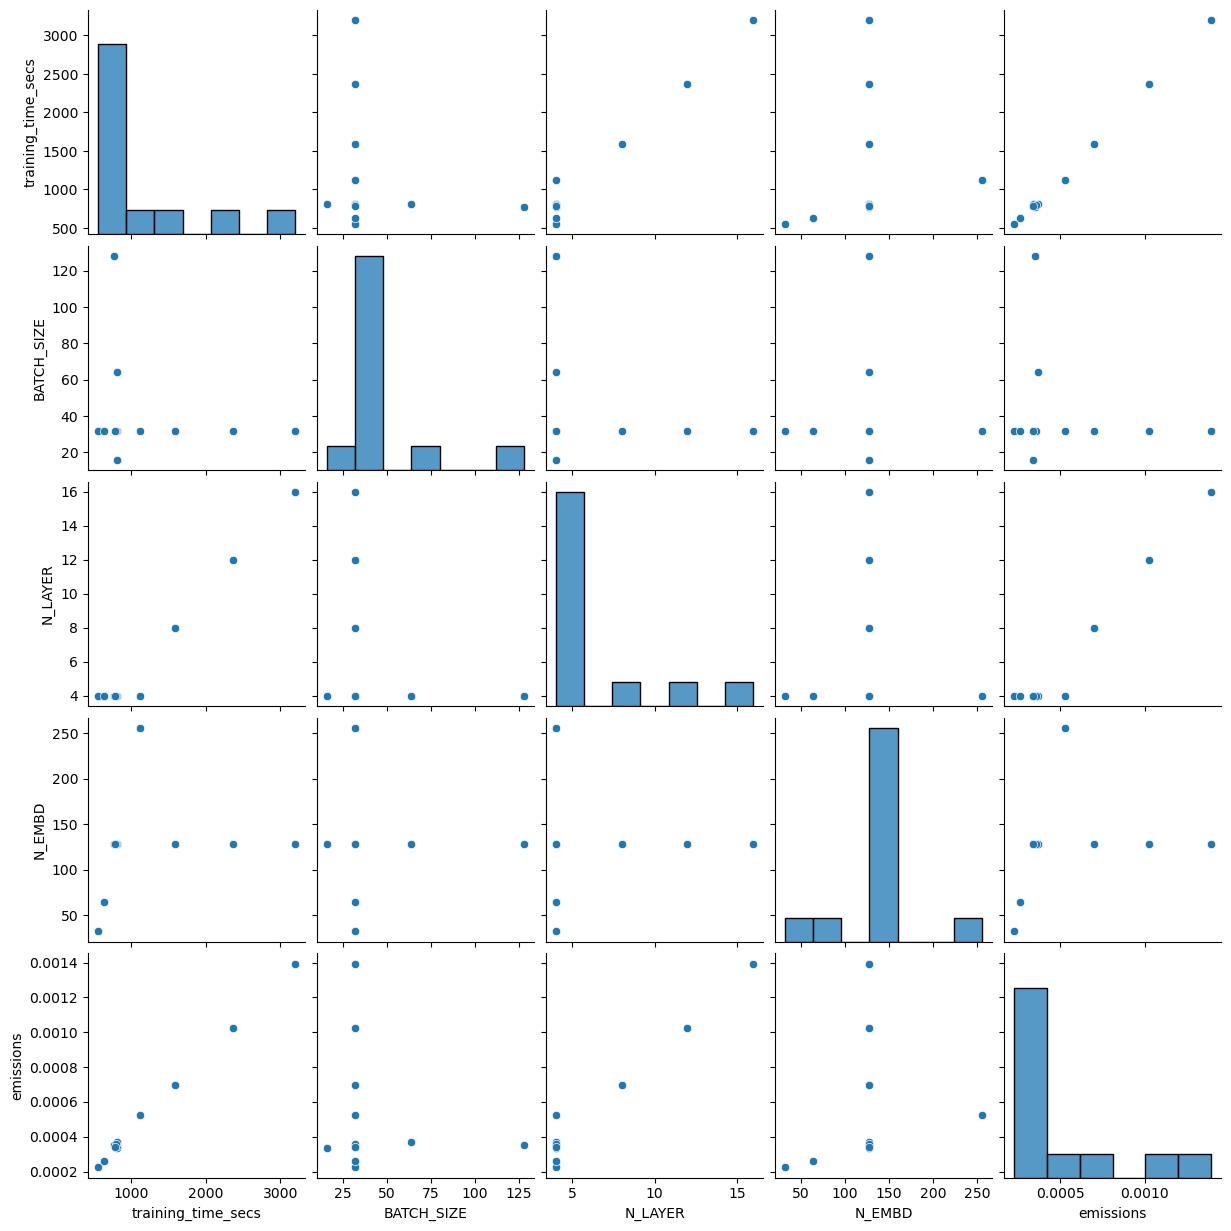

In [15]:
training_phase_data = training_phase_data_raw[training_phase_data_raw["DEVICE"] == "cpu"]
training_phase_data = training_phase_data[["training_time_secs","BATCH_SIZE", "N_LAYER", "N_EMBD" ,"emissions"]]

sns.pairplot(data=training_phase_data)

In [8]:
lm_train = smf.ols("emissions ~ BATCH_SIZE + N_LAYER + N_EMBD", data=training_phase_data).fit()
print(lm_train.summary())

                            OLS Regression Results                            
Dep. Variable:              emissions   R-squared:                       0.438
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                     5.187
Date:                Fri, 08 May 2026   Prob (F-statistic):            0.00818
Time:                        11:31:10   Log-Likelihood:                 166.38
No. Observations:                  24   AIC:                            -324.8
Df Residuals:                      20   BIC:                            -320.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0001      0.000     -0.544      0.5

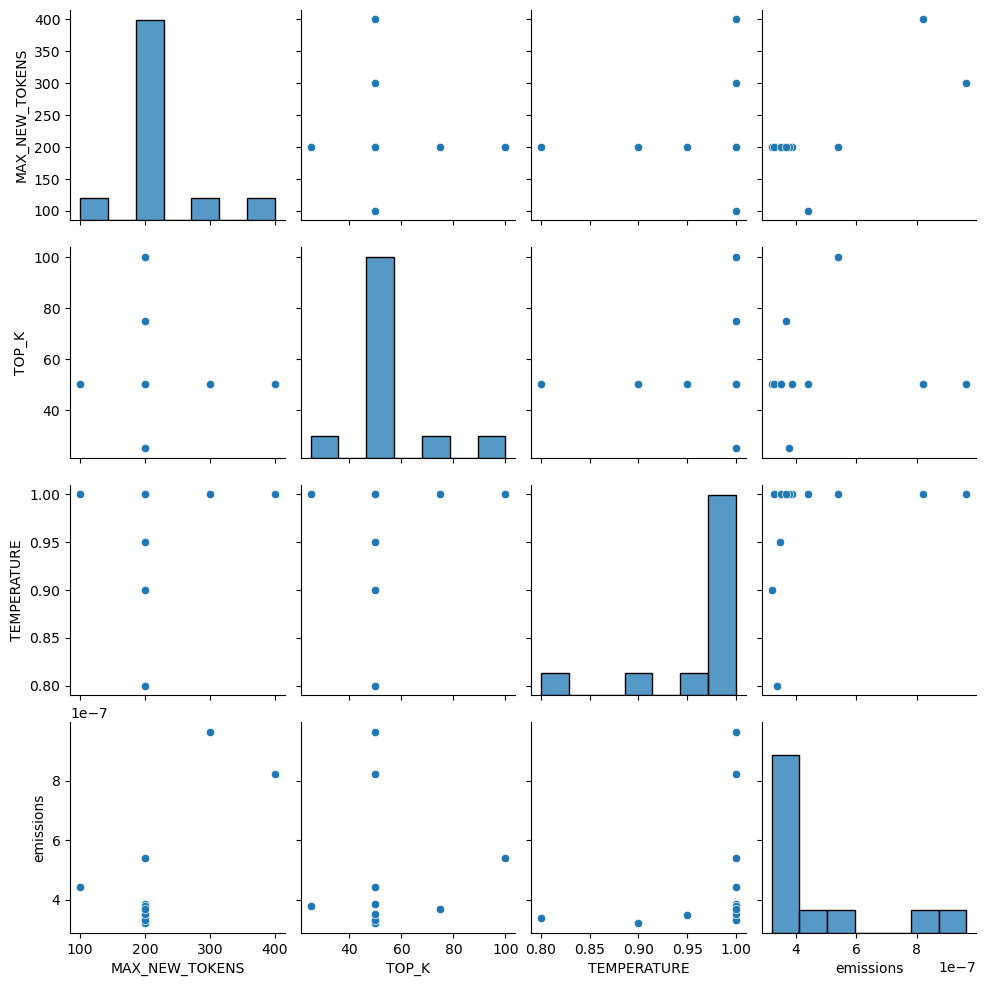

In [4]:
prompting_phase_data = prompting_phase_data_raw[["MAX_NEW_TOKENS", "TOP_K", "TEMPERATURE" ,"emissions"]]

sns.pairplot(data=prompting_phase_data)

In [5]:
lm_prompt = smf.ols("emissions ~ MAX_NEW_TOKENS + TOP_K + TEMPERATURE", data=prompting_phase_data).fit()
print(lm_prompt.summary())

                            OLS Regression Results                            
Dep. Variable:              emissions   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.471
Method:                 Least Squares   F-statistic:                     4.266
Date:                Fri, 08 May 2026   Prob (F-statistic):             0.0448
Time:                        00:30:17   Log-Likelihood:                 173.71
No. Observations:                  12   AIC:                            -339.4
Df Residuals:                       8   BIC:                            -337.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -7.835e-07   7.29e-07     -1.